<a href="https://colab.research.google.com/github/danielchin-ck/ADALL_github/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hello world")

hello world


In [2]:
import pandas as pd
# Example: Replace this with the raw URL of your GitHub file
github_raw_url = 'https://raw.githubusercontent.com/danielchin-ck/ADALL_github/main/laptop_prices_2024_sgd_TL.csv'
try:
  df = pd.read_csv(github_raw_url)
  print("Successfully loaded data from GitHub!")
  display(df.head())
except Exception as e:
  print(f"Error loading data: {e}")
  print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")


Successfully loaded data from GitHub!


,Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,3.27,2413.36,5,144.80
1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,5.03,1773.75,5,124.16
2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,4.41,1634.07,5,98.04
3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,2.16,2362.59,5,118.13
4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,6.93,2218.55,5,155.30


## Exploratory Data Analysis (EDA)

### 1. Data Structure and Basic Information

In [3]:
# Display basic information about the DataFrame, including data types and non-null values
print("Dataset Information:")
df.info()

# Display the shape of the DataFrame (number of rows and columns)
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Model             1000 non-null   object 
 2   CPU               1000 non-null   object 
 3   GPU               1000 non-null   object 
 4   RAM_GB            1000 non-null   int64  
 5   Storage_Type      1000 non-null   object 
 6   Storage_GB        1000 non-null   int64  
 7   Touchscreen       1000 non-null   bool   
 8   Weight_kg         1000 non-null   float64
 9   Screen_Size_inch  1000 non-null   float64
 10  Discount_percent  1000 non-null   float64
 11  Price_SGD         1000 non-null   float64
 12  Brand_Discount    1000 non-null   int64  
 13  Member_Discount   1000 non-null   float64
dtypes: bool(1), float64(5), int64(3), object(5)
memory usage: 102.7+ KB

Dataset Shape: 1000 rows, 14 columns


### 2. Duplicate Removal

In [4]:
# Check for duplicate rows
initial_rows = df.shape[0]
duplicates_found = df.duplicated().sum()

if duplicates_found > 0:
  # Remove duplicate rows if any are found
  df.drop_duplicates(inplace=True)
  print(f"Duplicates Removed: {duplicates_found} duplicate rows found and removed.")
  print(f"New Dataset Shape after removing duplicates: {df.shape[0]} rows, {df.shape[1]} columns")
else:
  print("No duplicate rows found.")

No duplicate rows found.


### 3. Descriptive Statistics for Numerical Columns

In [5]:
# Display descriptive statistics for numerical columns
# This includes count, mean, standard deviation, min, max, and quartiles.
print("Descriptive Statistics for Numerical Columns:")
display(df.describe())

Descriptive Statistics for Numerical Columns:


,RAM_GB,Storage_GB,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000
mean,53.128000,1505.024000,2.036560,15.645700,7.538230,2277.796410,6.7680,135.810660
std,44.413288,1380.203919,0.746477,1.759846,4.334012,616.496246,2.6346,41.344593
min,8.000000,256.000000,1.000000,13.300000,0.000000,995.770000,3.0000,50.740000
25%,16.000000,512.000000,1.340000,14.000000,3.815000,1776.212500,5.0000,103.435000
50%,32.000000,1024.000000,1.970000,15.600000,7.480000,2257.765000,7.0000,131.095000
75%,64.000000,2048.000000,2.680000,17.300000,11.225000,2711.680000,10.0000,163.052500
max,128.000000,4096.000000,3.500000,18.400000,15.000000,4156.500000,10.0000,281.340000


### 4. Missing Values Analysis

In [6]:
# Check for missing values in each column
print("Missing Values per Column:")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0] # Filter to show only columns with missing values

if not missing_values.empty:
  display(missing_values.sort_values(ascending=False))
else:
  print("No missing values found in the dataset.")

Missing Values per Column:
No missing values found in the dataset.


### 5. Unique Values in Key Categorical Columns

In [7]:
# Identify and display unique values for selected categorical columns
print("Unique Values in Key Categorical Columns:")
# Corrected categorical_cols list based on df.info() and available columns
categorical_cols = ['Brand', 'CPU', 'Storage_Type', 'GPU'] # Adjusted to actual column names

for col in categorical_cols:
  if col in df.columns:
    print(f"\nUnique values and their counts for '{col}':")
    # Display top 10 unique values and their counts to quickly spot inconsistencies
    display(df[col].value_counts().head(10))
  else:
    print(f"Column '{col}' not found in the dataset (This should not happen with the corrected list).")

Unique Values in Key Categorical Columns:

Unique values and their counts for 'Brand':


,count
Brand,
Asus,177
Acer,176
Microsoft,174
Lenovo,174
Dell,163
HP,136



Unique values and their counts for 'CPU':


,count
CPU,
Intel i5-14600H,114
Intel i7-14800H,106
Intel i9-14900HK,103
Intel i5-14500H,102
Intel i7-14700H,101
AMD Ryzen 5 8600H,101
Intel Core Ultra 7 15500H,99
Intel Core Ultra 9 15700H,96
AMD Ryzen 9 8900HX,93


Column 'OS' not found in the dataset.
Column 'Storage Type' not found in the dataset.
Column 'Graphics' not found in the dataset.


### 6. Data Issues and Suggestions for Data Quality Improvement

In [8]:
print("Potential Data Issues and Quality Improvement Suggestions:")

# Suggestion for 'Brand' column if inconsistencies are observed
if 'Brand' in df.columns:
  print("\n- **'Brand' column**: Check for inconsistent casing (e.g., 'acer' vs 'Acer') or alternative spellings. Consider standardizing names to a consistent format (e.g., all lowercase or title case). Although current value counts look clean, this is a general good practice for categorical data.")
  print(f"  Current unique brands: {df['Brand'].nunique()} (If this number is higher than expected, investigate for variations).")

# RAM and Storage columns are already numeric (RAM_GB, Storage_GB)
# The previous check was for generic 'Storage' or 'RAM' as object type, which is not the case here.
if 'RAM_GB' in df.columns and df['RAM_GB'].dtype == 'object': # Redundant given df.info() but kept for robustness
    print("\n- **'RAM_GB' column**: Appears to be of object (string) type but should contain numerical data. Needs conversion.")
if 'Storage_GB' in df.columns and df['Storage_GB'].dtype == 'object': # Redundant given df.info() but kept for robustness
    print("\n- **'Storage_GB' column**: Appears to be of object (string) type but should contain numerical data. Needs conversion.")

# Price column is already numeric (Price_SGD)
if 'Price_SGD' in df.columns:
  if df['Price_SGD'].dtype == 'object': # Redundant given df.info() but kept for robustness
    print("\n- **'Price_SGD' column**: Currently an object type. Ensure it is converted to a numeric type (float/int) for proper analysis. Look for and remove currency symbols (e.g., '$', '€') or thousands separators (',') before conversion. Invalid price entries should be handled.")
  else:
    print("\n- **'Price_SGD' column**: Consider analyzing outliers. Extremely high or low prices could indicate data entry errors or unique product configurations. Visualizations like box plots can help identify these.")

# General suggestions based on missing values
missing_values_count = df.isnull().sum().sum()
if missing_values_count > 0:
  print(f"\n- **Handling Missing Values**: For the {missing_values_count} missing values identified across columns, consider imputation strategies (e.g., mean, median, mode for numerical; mode for categorical) or removal of rows/columns, depending on the extent and nature of missingness. The choice of strategy should align with the data's domain and subsequent analysis goals.")
else:
  print("\n- **No Missing Values**: The dataset is complete in terms of missing entries, which is a strong point for data quality.")

print("\n- **Review Column Names**: Ensure all column names are consistent, descriptive, and user-friendly (e.g., no special characters, consistent casing like `snake_case` or `camelCase`). Your current column names like `RAM_GB` and `Price_SGD` are good examples of clarity.")
print("- **Data Type Consistency**: Verify that all columns have appropriate data types. `df.info()` showed appropriate types for most columns, which is excellent.")
print("- **Outlier Detection**: Beyond `Price_SGD`, check other numerical columns (`RAM_GB`, `Storage_GB`, `Weight_kg`, `Screen_Size_inch`, `Discount_percent`, `Brand_Discount`, `Member_Discount`) for outliers that might skew statistical analyses or model training. Visualizations like box plots are highly recommended.")
print("- **Standardization/Normalization**: Depending on future modeling needs, numerical features might benefit from standardization or normalization to bring them to a common scale.")
print("- **Feature Engineering**: For text-based columns like `Model`, `CPU`, `GPU`, consider extracting more detailed features if needed for advanced analysis or modeling (e.g., CPU generation, GPU series).")

Potential Data Issues and Quality Improvement Suggestions:

- **'Brand' column**: Check for inconsistent casing (e.g., 'acer' vs 'Acer') or alternative spellings. Consider standardizing names to a consistent format (e.g., all lowercase or title case).
  Current unique brands: 6 (If this number is higher than expected, investigate for variations).

- **No Missing Values**: The dataset is complete in terms of missing entries, which is a strong point for data quality.

- **Review Column Names**: Ensure all column names are consistent, descriptive, and user-friendly (e.g., no special characters, consistent casing like `snake_case` or `camelCase`).
- **Data Type Consistency**: Verify that all columns have appropriate data types. Incorrect data types can lead to inaccurate analysis and inefficient memory usage.
- **Outlier Detection**: Beyond price, check other numerical columns for outliers that might skew statistical analyses or model training.
- **Standardization/Normalization**: Dependin

### 7. Outlier Detection and Distribution Analysis (Numerical Columns)

Visualizing Numerical Column Distributions and Outliers:


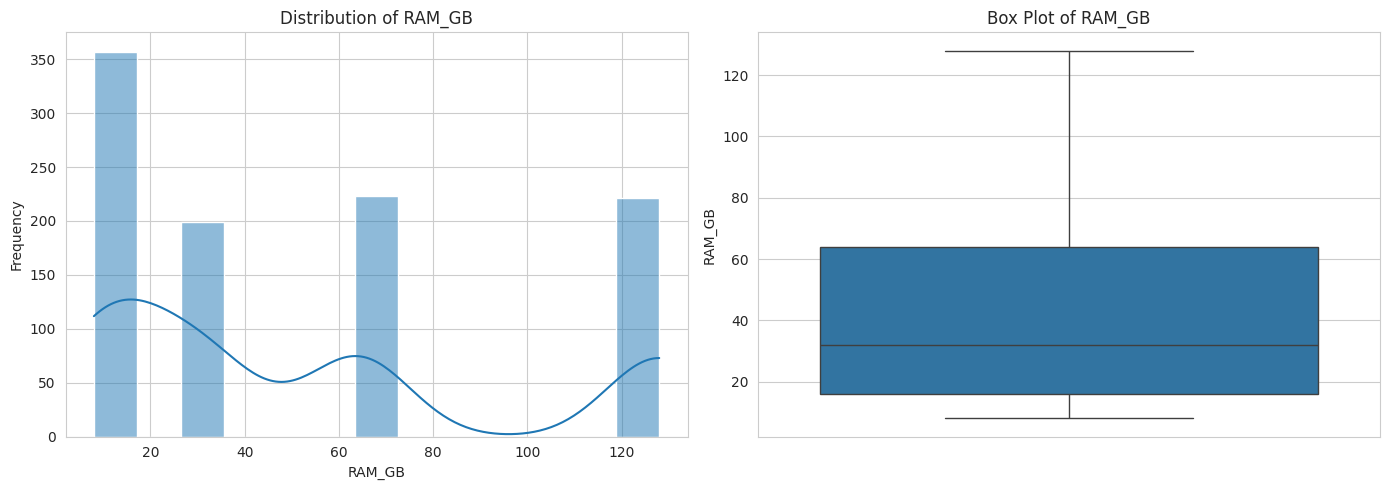

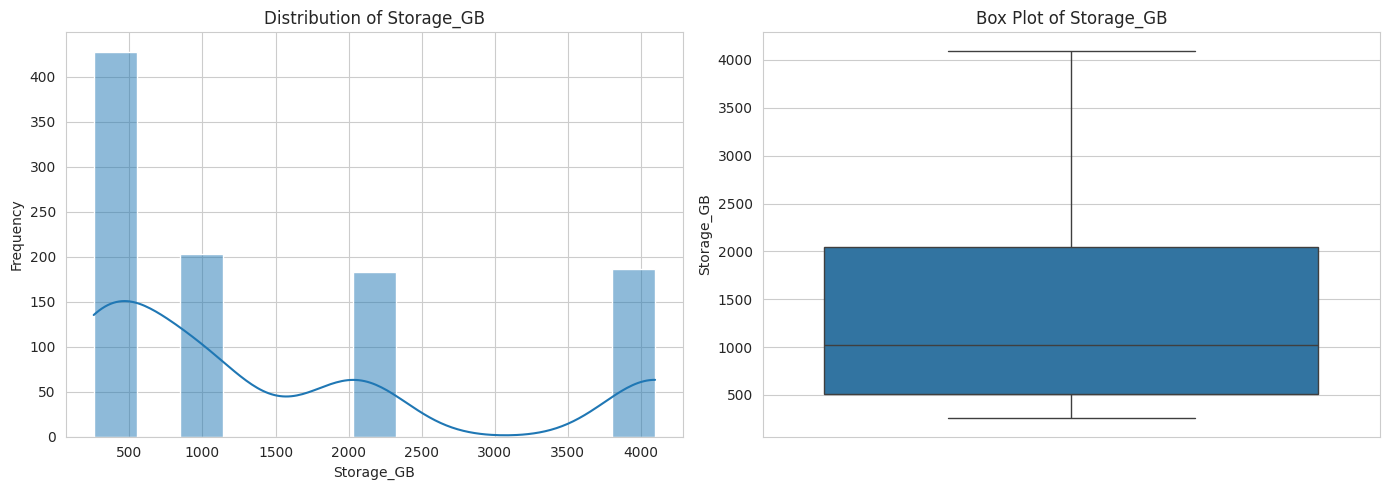

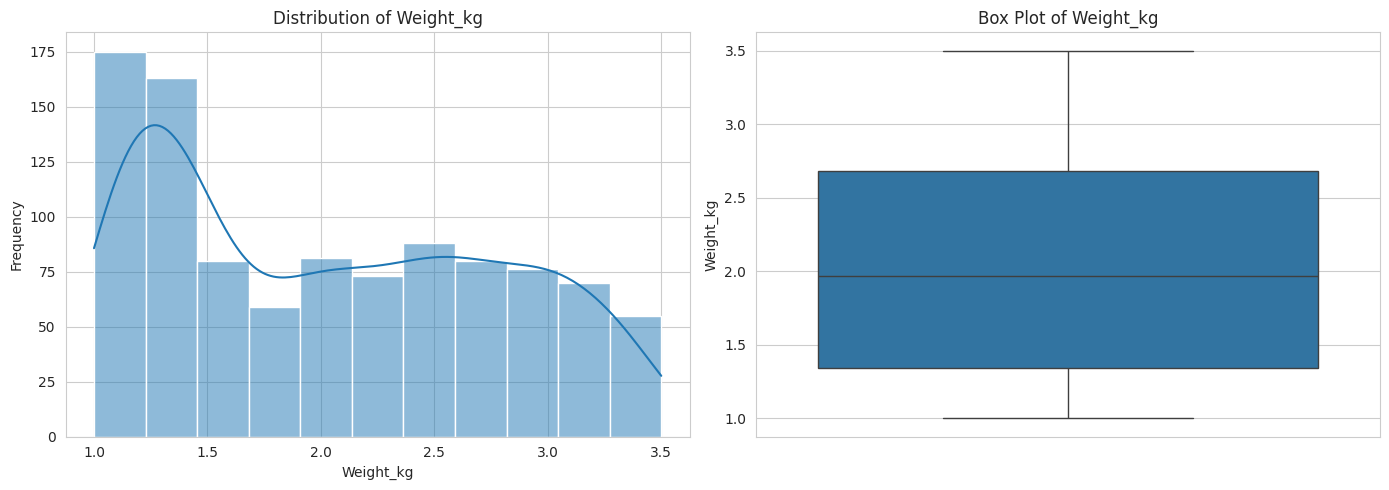

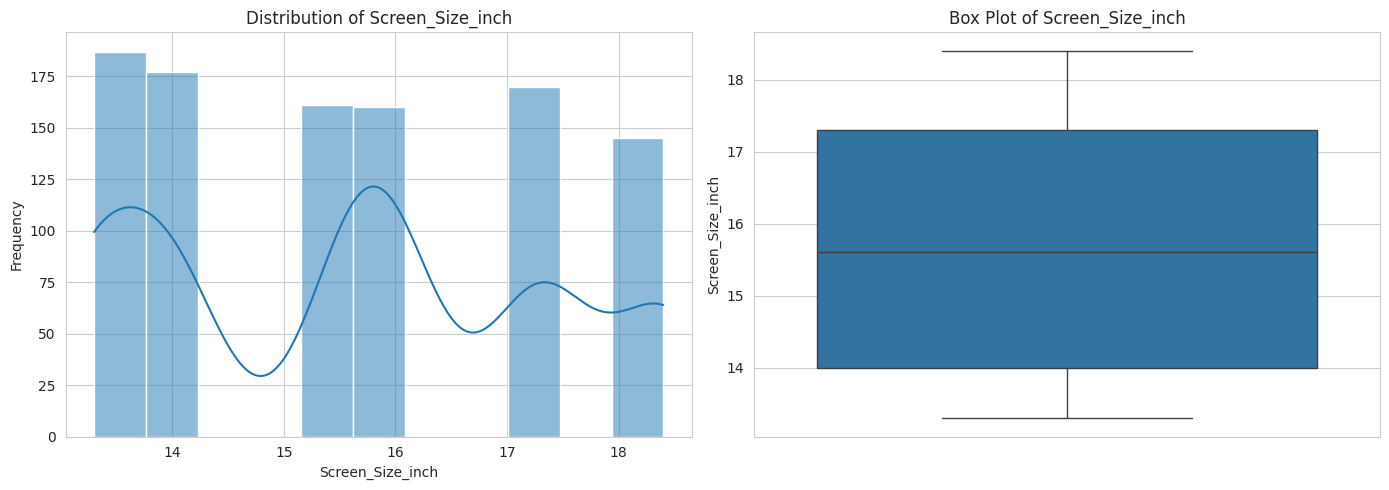

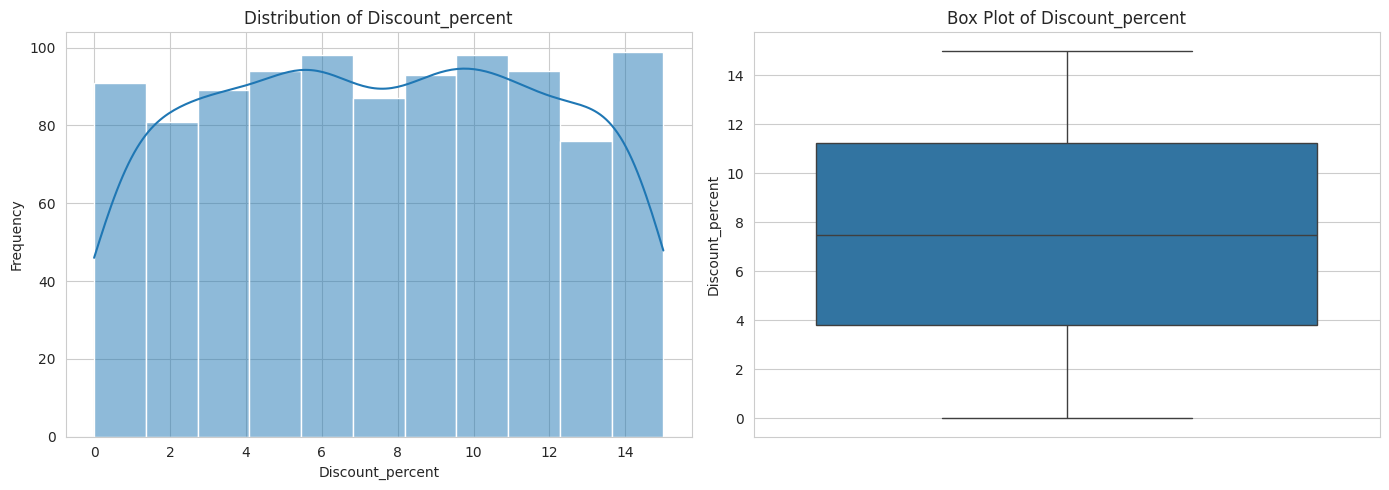

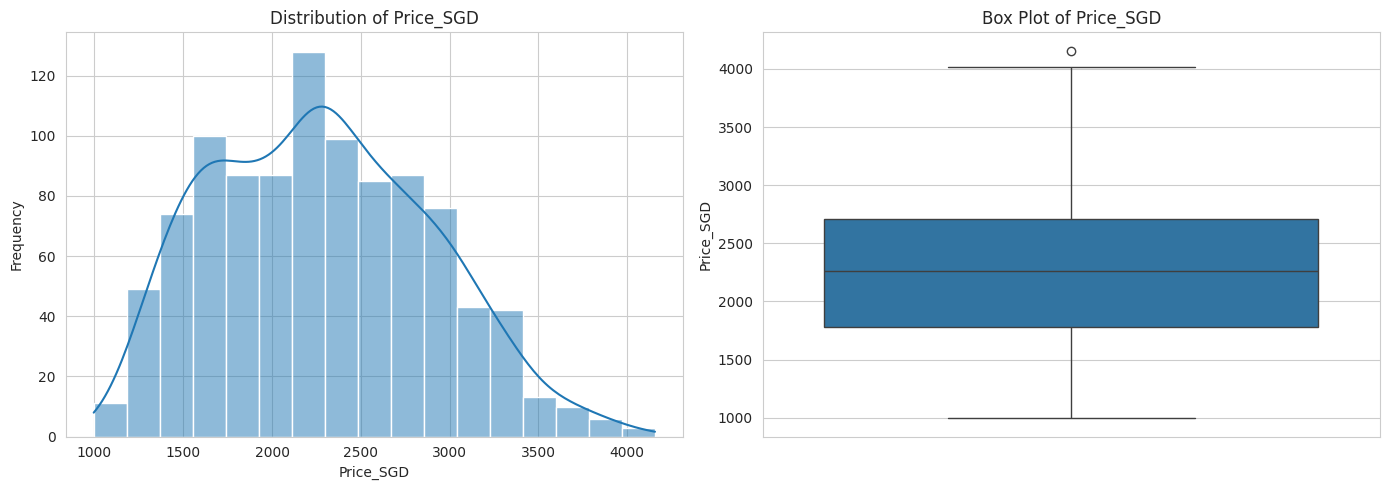


--- Observations from Outlier and Distribution Analysis ---

Review the generated plots for each numerical column. Key things to observe:
1. **Histograms**: Check the shape of the distribution (normal, skewed, multimodal). This helps understand the common ranges and spread of values.
2. **Box Plots**: Look for points outside the 'whiskers'. These are potential outliers. Assess if these outliers are valid data points (e.g., premium products, high-end specifications) or potential data entry errors.

Based on the plots, we can decide if any outlier treatment (e.g., capping, removal) or data transformation (e.g., log transformation for skewed data) is necessary for future modeling.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualizing Numerical Column Distributions and Outliers:")

# Identify numerical columns (excluding boolean and potentially ID-like columns if any)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude 'Brand_Discount' and 'Member_Discount' as they might be more categorical or derived
numerical_cols = [col for col in numerical_cols if col not in ['Brand_Discount', 'Member_Discount']]

# Set a style for the plots
sns.set_style("whitegrid")

# Plotting histograms and box plots for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(14, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Box plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

print("\n--- Observations from Outlier and Distribution Analysis ---")
print("\nReview the generated plots for each numerical column. Key things to observe:")
print("1. **Histograms**: Check the shape of the distribution (normal, skewed, multimodal). This helps understand the common ranges and spread of values.")
print("2. **Box Plots**: Look for points outside the 'whiskers'. These are potential outliers. Assess if these outliers are valid data points (e.g., premium products, high-end specifications) or potential data entry errors.")
print("\nBased on the plots, we can decide if any outlier treatment (e.g., capping, removal) or data transformation (e.g., log transformation for skewed data) is necessary for future modeling.")